In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("../data/processed/featured_marketing_data.csv")
df.head()

,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,...,QUARTER,DAY_OF_WEEK,TOTAL_MARKETING_SPEND,LOG_REVENUE,TOTAL_CLICKS,TOTAL_IMPRESSIONS,CTR,TOTAL_PURCHASES,ROAS,DIGITAL_SPEND
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-29,USD,22,...,3,4,439.278905,8.423758,418.0,50904.0,0.008211,27,10.364678,439.278905
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-30,USD,14,...,3,5,525.922025,8.064321,476.0,64671.0,0.007360,17,6.042717,525.922025
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-31,USD,31,...,3,6,701.946429,8.607034,553.0,82891.0,0.006671,39,7.791191,701.946429
3,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-01,USD,18,...,3,0,652.532798,8.112819,531.0,81525.0,0.006513,22,5.112341,652.532798
4,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-02,USD,23,...,3,1,610.972971,8.292295,503.0,71244.0,0.007060,28,6.533820,610.972971


In [4]:
features = [

"GOOGLE_PAID_SEARCH_SPEND",
"GOOGLE_SHOPPING_SPEND",
"GOOGLE_PMAX_SPEND",
"GOOGLE_DISPLAY_SPEND",
"GOOGLE_VIDEO_SPEND",

"META_FACEBOOK_SPEND",
"META_INSTAGRAM_SPEND",
"META_OTHER_SPEND",

"TIKTOK_SPEND",

"TOTAL_CLICKS",
"TOTAL_IMPRESSIONS",

"YEAR",
"MONTH",
"QUARTER",
"DAY_OF_WEEK"

]

target = "LOG_REVENUE"

In [5]:
X = df[features]
y = df[target]

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [6]:
baseline_revenue = rf.predict(X).mean()
print("Baseline Revenue:", baseline_revenue)

Baseline Revenue: 9.000992881807719


In [7]:
simulation_1 = X.copy()
simulation_1["META_FACEBOOK_SPEND"] *= 1.20
simulation_1["META_INSTAGRAM_SPEND"] *= 0.80

In [8]:
scenario1_rev = rf.predict(
    simulation_1
).mean()
scenario1_pct = (
    (scenario1_rev - baseline_revenue)
    / baseline_revenue
) * 100
print("Scenario Revenue:", scenario1_rev)
print(
    f"Improvement: {scenario1_pct:.2f}%"
)

Scenario Revenue: 9.007476135835946
Improvement: 0.07%


In [9]:
#Scenario 2
simulation_2 = X.copy()
simulation_2["GOOGLE_SHOPPING_SPEND"] *= 1.30
simulation_2["TIKTOK_SPEND"] *= 0.70

In [10]:
scenario2_rev = rf.predict(simulation_2).mean()
scenario2_pct = (
    (scenario2_rev - baseline_revenue)
    / baseline_revenue
) * 100
print("Scenario 2 Revenue:", scenario2_rev)
print("Improvement %:", scenario2_pct)

Scenario 2 Revenue: 9.042283841701018
Improvement %: 0.4587378352087578


In [11]:
# Scenario 3
simulation_3 = X.copy()
# Increase good channels
simulation_3["GOOGLE_SHOPPING_SPEND"] *= 1.30
simulation_3["META_FACEBOOK_SPEND"] *= 1.25
simulation_3["GOOGLE_PAID_SEARCH_SPEND"] *= 1.20
# Reduce poor channels
simulation_3["META_INSTAGRAM_SPEND"] *= 0.60
simulation_3["TIKTOK_SPEND"] *= 0.60
simulation_3["GOOGLE_PMAX_SPEND"] *= 0.80


In [12]:
scenario3_rev = rf.predict(simulation_3).mean()
scenario3_pct = (
    (scenario3_rev - baseline_revenue)
    / baseline_revenue
) * 100
print("Scenario 3 Revenue:", scenario3_rev)
print("Improvement %:", scenario3_pct)

Scenario 3 Revenue: 9.032430344431189
Improvement %: 0.34926660909831564


In [13]:
results_table = pd.DataFrame({

    "Scenario":[
        "Baseline",
        "Facebook +20% / Instagram -20%",
        "Google Shopping +30% / TikTok -30%",
        "Optimal Mix"
    ],

    "Revenue":[
        baseline_revenue,
        scenario1_rev,
        scenario2_rev,
        scenario3_rev
    ],

    "Improvement_%":[
        0,
        scenario1_pct,
        scenario2_pct,
        scenario3_pct
    ]

})

results_table

,Scenario,Revenue,Improvement_%
0,Baseline,9.000993,0.000000
1,Facebook +20% / Instagram -20%,9.007476,0.072028
2,Google Shopping +30% / TikTok -30%,9.042284,0.458738
3,Optimal Mix,9.032430,0.349267


In [14]:
results_table.to_csv(
    "../results/budget_optimization_results.csv",
    index=False
)

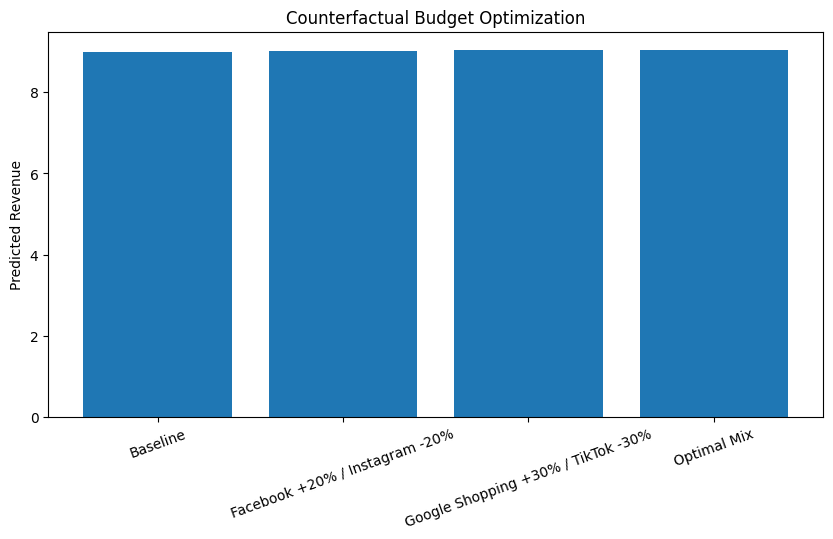

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(results_table["Scenario"],results_table["Revenue"])
plt.title("Counterfactual Budget Optimization")
plt.ylabel("Predicted Revenue")
plt.xticks(rotation=20)

plt.show()

In [13]:
results_table["Improvement_%"] = [
    0,
    scenario1_pct,
    scenario2_pct,
    scenario3_pct
]

results_table

,Scenario,Predicted_Revenue,Improvement_%
0,Baseline,9.000993,0.000000
1,"Facebook +20%, Instagram -20%",9.007476,0.072028
2,"Google Shopping +30%, TikTok -30%",9.042284,0.458738
3,Optimal Mix,9.032430,0.349267


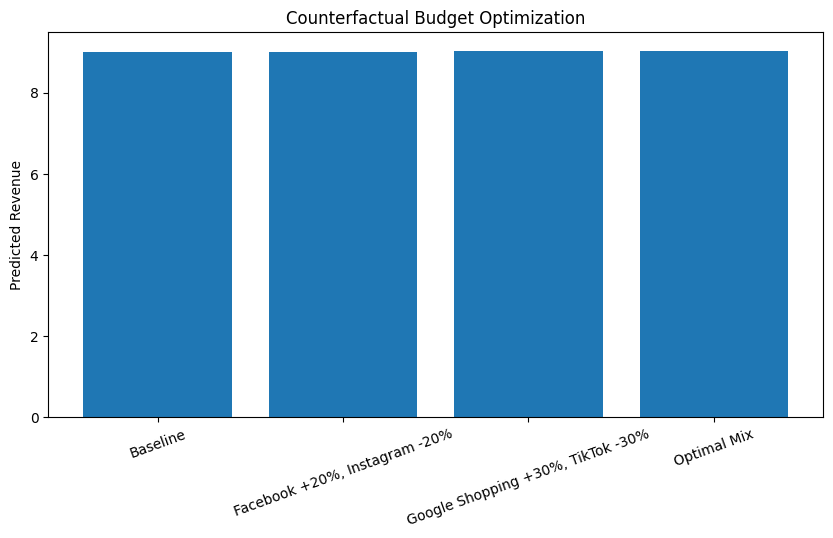

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results_table["Scenario"],
    results_table["Predicted_Revenue"]
)

plt.title("Counterfactual Budget Optimization")
plt.ylabel("Predicted Revenue")
plt.xticks(rotation=20)

plt.show()

In [15]:
import os

os.makedirs("../results", exist_ok=True)

In [16]:
results_table.to_csv("../results/budget_optimization_results.csv",index=False)